[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/Entornos_Complejos/Deep_Q_Learning.ipynb)

## **1. Deep Q-Learning para MountainCarContinuous**

### Clonado de repositorio y ubicación en directorio correcto

In [ ]:
!git clone https://github.com/ddumu/dourado-minguell-eml-mia-um-p1
%cd dourado-minguell-eml-mia-um-p1/Entornos_Complejos/
%ls

### Instalación de dependencias

In [ ]:
# %%capture
%pip install gymnasium
%pip install matplotlib tqdm numpy torch
%pip install "gymnasium[classic-control]"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Importado de librerias

In [ ]:
import os
import gc
import random
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import deque
from tqdm import tqdm
from IPython.display import HTML

from src.experiment.deep_functions import train_dqn, plot, plot_episodes_length, plot_policy_episodes, pi_star_from_Q

### Replicabilidad

In [ ]:
# Configuración de Hardware y Semillas
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 2024

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

ENV_NAME = "MountainCarContinuous-v0"

### Generación de entorno

In [ ]:
env = gym.make(ENV_NAME, render_mode="rgb_array")
env.reset(seed=SEED)

(array([-0.46483374,  0.        ], dtype=float32), {})

## **3. Experimentación**  

In [ ]:
Q_net4, action_grid4, list_stats4, list_episodes_length4 = train_dqn(
    env_name=ENV_NAME, 
    num_episodes=2000, 
    epsilon_init=1,
    train_every=4,
    learning_rate = 1e-3
)

 10%|█         | 202/2000 [01:35<04:20,  6.91it/s]

Episodio 200 -> Reward medio acumulado: 44.8952, Epsilon: 0.3651


 20%|██        | 404/2000 [02:00<02:19, 11.43it/s]

Episodio 400 -> Reward medio acumulado: 93.5060, Epsilon: 0.1340


 30%|███       | 602/2000 [02:19<02:00, 11.63it/s]

...

 80%|████████  | 1603/2000 [03:41<00:25, 15.56it/s]

Episodio 1600 -> Reward medio acumulado: 93.5353, Epsilon: 0.0500


 90%|█████████ | 1803/2000 [03:57<00:16, 12.06it/s]

Episodio 1800 -> Reward medio acumulado: 93.5765, Epsilon: 0.0500


100%|██████████| 2000/2000 [04:10<00:00,  7.99it/s]


#### Evaluación

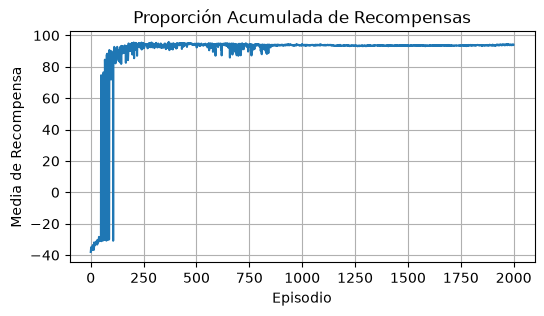

Última recompensa media calculada: 94.07


In [ ]:
plot(list_stats4)
print(f"Última recompensa media calculada: {list_stats4[-1]:.2f}")

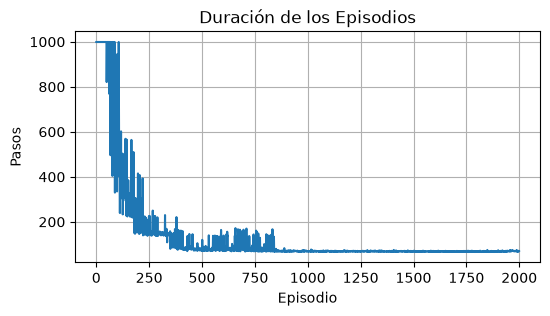

Máxima duración registrada en un episodio: 999 pasos


In [ ]:
plot_episodes_length(list_episodes_length4)
print(f"Máxima duración registrada en un episodio: {max(list_episodes_length4)} pasos")

In [ ]:
pi, actions = pi_star_from_Q(env, Q_net4, action_grid4)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Render del entorno\n", env.render())

Política óptima obtenida
 Política completada con Recompensa Total: 90.74799984645844 
 Acciones 0.800, 0.800, 0.800, 0.800, 0.800, 0.800, 0.800, 0.800, 0.800, 0.800, 0.800, 0.900, 0.900, 0.900, 0.900... 
 Render del entorno
 [[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


In [ ]:
plot_policy_episodes(Q_net4, action_grid=action_grid4)